## Inspection Tool

### Packages

In [30]:
# Packages
import glob
import os
import geopandas as gpd
from resilientplotterclass import rpc
import rioxarray as rxr
from osgeo import gdal
from shapely.geometry import box
import time

### Merge intermediate results

In [2]:
# File paths
merge = True
file_path_cmems_ins = glob.glob(r"p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\03_merged\*.tif")
file_path_cmems_out = r"p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\intertidal_unclipped.tif"
print(f"Number of input files: {len(file_path_cmems_ins)}")
print(f"Output file path:      {file_path_cmems_out}")

# Function to merge rasters
def merge_rasters(file_paths_in, file_path_out, file_path_vrt=None):
    # Enable GDAL exceptions
    gdal.UseExceptions()
    
    # Get the file paths
    if file_path_vrt is None:
        file_path_vrt = os.path.join(os.path.dirname(file_path_out), "temp.vrt")

    # Remove existing VRT file if it exists
    if os.path.exists(file_path_vrt):
        os.remove(file_path_vrt)
    
    # Remove existing output file if it exists
    if os.path.exists(file_path_out):
        os.remove(file_path_out)
    
    # Create a VRT file and then translate it to GTiff
    gdal.BuildVRT(file_path_vrt, file_paths_in)
    gdal.Translate(file_path_out, file_path_vrt, format="GTiff", creationOptions=["COMPRESS=LZW"])
    os.remove(file_path_vrt)

if merge:
    print("Merging rasters")
    t0 = time.time()
    #merge_rasters(file_path_cmems_ins, file_path_cmems_out)
    t1 = time.time()
    print(f"Time taken to merge rasters: {(t1 - t0) / 60:.2f} minutes")

Number of input files: 14960
Output file path:      p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\intertidal_unclipped.tif
Merging rasters
Time taken to merge rasters: 0.00 minutes


### Settings

In [31]:
# File paths
file_path_cmems_ncs = glob.glob(r"p:\11209821-cmems-global-sdb\08_projectdeliverables\*.nc")
file_path_cmems_tifs = [r"p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\intertidal_unclipped.tif"]
file_path_cmems_in = {os.path.basename(file_path).split(".")[0].split(" ")[-1]: file_path for file_path in file_path_cmems_ncs + file_path_cmems_tifs}

# Sort file paths
file_path_cmems_in = dict(sorted(file_path_cmems_in.items()))

# Print file paths
pad = len(max(file_path_cmems_in.keys(), key=len))
for key, value in file_path_cmems_in.items():
    print(f"{key:<{pad}}: {value}")

RTE                 : p:\11209821-cmems-global-sdb\08_projectdeliverables\Global SDB 2025 RTE.nc
Wave                : p:\11209821-cmems-global-sdb\08_projectdeliverables\Global SDB 2025 Wave.nc
combined            : p:\11209821-cmems-global-sdb\08_projectdeliverables\Global SDB 2025 combined.nc
intertidal          : p:\11209821-cmems-global-sdb\08_projectdeliverables\Global SDB 2025 intertidal.nc
intertidal_unclipped: p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\intertidal_unclipped.tif


### Area of interest

In [ ]:
# Packages for draw map
import xyzservices
from ipyleaflet import DrawControl, Map, basemaps
from ipywidgets import Layout
import geopandas as gpd
from shapely.geometry import base

# Class to draw and manage geometries on a map
class draw_map(Map):
    """
    A class to create a map to draw and manage geometries
    """

    style = {"color": "#ff0000", "weight": 2, "opacity": 0.3}

    def __init__(
        self,
        center: tuple[float] = None,
        zoom: int = 8,
        basemap: xyzservices.TileProvider = basemaps.OpenStreetMap.Mapnik,
        file_path_gdf: str = None,
        geometries: list[base.BaseGeometry] = None,
        **kwargs,
    ):

        # Set geometries from file
        gdf = None
        if not file_path_gdf:
            gdf = gpd.read_file(file_path_gdf).to_crs("EPSG:4326")
        elif not geometries:
            gdf = gpd.GeoDataFrame(geometry=geometries, crs="EPSG:4326")

        # Get center of the map
        if center is None and gdf is not None and not gdf.empty:
            centroid = gdf.geometry.union_all().representative_point()
            center = (centroid.y, centroid.x)

        # Set default kwargs
        kwargs.setdefault("scroll_wheel_zoom", True)  # Enable scroll wheel zoom
        kwargs.setdefault("attribution_control", False)  # Disable attribution control
        kwargs.setdefault("layout", Layout(height="600px", width="100%"))  # Set layout height and width

        # Initialize Map superclass
        super().__init__(center=center, zoom=zoom, basemap=basemap, **kwargs)

        # Initialise draw control
        self.draw_control = DrawControl(
            polygon={"shapeOptions": self.style},
            rectangle={"shapeOptions": self.style},
            circlemarker={"shapeOptions": self.style},
            polyline={"shapeOptions": self.style},
        )

        # Add draw control to the map
        self.add_control(self.draw_control)

        # Set geometries from GeoDataFrame if available
        if gdf is not None and not gdf.empty:
            self.set_gdf(gdf)

    def set_gdf(self, gdf: gpd.GeoDataFrame) -> None:
        """
        Set the geometries from a GeoDataFrame to the map.

        Args:
            aoi (gpd.GeoDataFrame): The GeoDataFrame containing the geometries.

        Returns:
            None
        """
        # Update draw flag
        self.drawn = True

        # Add style to GeoDataFrame
        gdf["style"] = [self.style] * len(gdf)

        # Add geometries to the draw control
        self.draw_control.data = self.draw_control.data + list(gdf.iterfeatures())
        
    def get_gdf(self, crs: str = "EPSG:4326") -> gpd.GeoDataFrame:
        """
        Get the geometries from the map as a GeoDataFrame.

        Args:
            crs (str): The coordinate reference system to reproject the geometries to.
        Returns:
            gpd.GeoDataFrame: A GeoDataFrame containing the geometries from the map.
        """
        # Get geometries from the map
        if not self.draw_control.data:
            gdf = gpd.GeoDataFrame(columns=["geometry"], crs="EPSG:4326")
        else:
            gdf = gpd.GeoDataFrame.from_features(self.draw_control.data, crs="EPSG:4326").drop(columns="style")

        # Reproject geometries
        gdf = gdf.to_crs(crs)

        return gdf

In [36]:
# Specify area of interest using file
file_path_aoi = None

# Specify area of interest using geometry
geometries = [box(4.5, 52.8, 6.0, 53.5)]
geometries = None

# Initialize map (on Netherlands)
map = draw_map(zoom=9, file_path_gdf=file_path_aoi, geometries=geometries)

# Show map
map

TypeError: object of type 'NoneType' has no len()

In [15]:
# Get geometries from map
gdf_aoi = map.get_gdf()
gdf_aoi

,geometry
0,"POLYGON ((6 52.8, 6 53.5, 4.5 53.5, 4.5 52.8, ..."


### Read data

In [ ]:
# Read data
def read_data(file_path, bounds):
    # Read data
    da = rxr.open_rasterio(file_path, masked=True).isel(band=0)["elevation"]

    # Clip data
    da = da.rio.clip_box(*bounds)

    # Reproject data
    da = da.rio.reproject("EPSG:4326")

    # Set attributes
    da.attrs["long_name"] = "Bathymetry"
    da.attrs["units"] = "m MSL"

    return da

# Read data
da_combined = read_data(file_path_cmems_in["combined"], gdf_aoi.total_bounds)
da_RTE = read_data(file_path_cmems_in["RTE"], gdf_aoi.total_bounds)
da_wave = read_data(file_path_cmems_in["Wave"], gdf_aoi.total_bounds)
da_intertidal = read_data(file_path_cmems_in["intertidal"], gdf_aoi.total_bounds)
#da_intertidal_unclipped = read_data(file_path_cmems_in["intertidal_unclipped"], gdf_aoi.total_bounds)

### Plot data

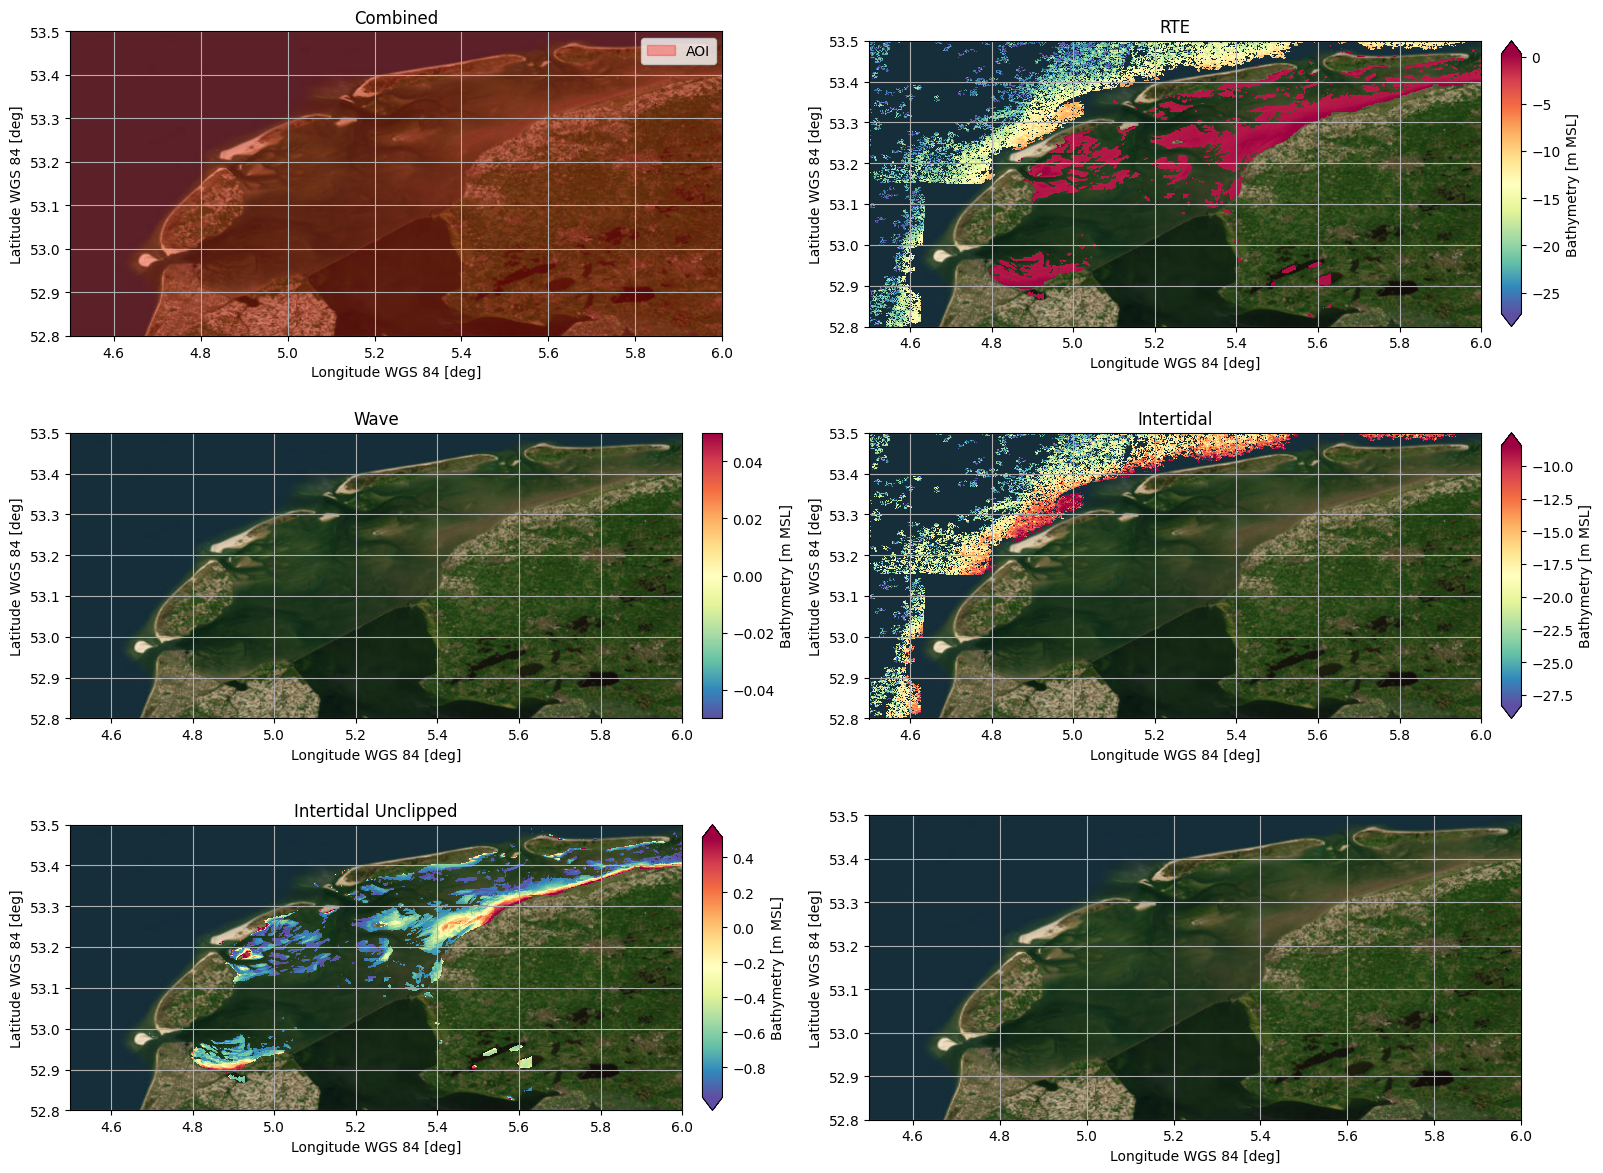

In [29]:
# Plot data
fig, axs = rpc.subplots(3, 2, figsize=(16, 12))
axs = axs.flatten()

rpc.geometries(gdf_aoi, ax=axs[0], color="red", alpha=0.3, label="AOI")
axs[0].legend()
rpc.imshow(da_combined, ax=axs[1], data_style="default", robust=True)
rpc.imshow(da_RTE, ax=axs[2], data_style="default", robust=True)
rpc.imshow(da_wave, ax=axs[3], data_style="default", robust=True)
rpc.imshow(da_intertidal, ax=axs[4], data_style="default", robust=True)
#rpc.imshow(da_intertidal, ax=axs[5], data_style="default", robust=True)


xlim = gdf_aoi.total_bounds[[0, 2]]
ylim = gdf_aoi.total_bounds[[1, 3]]

for ax, title in zip(axs, ["Combined", "RTE", "Wave", "Intertidal", "Intertidal Unclipped", ""]):
    rpc.basemap(crs=da_intertidal.rio.crs, ax=ax, map_style="satellite", xlim=xlim, ylim=ylim)
    ax.set_title(title)
rpc.show(fig=fig)